<a href="https://colab.research.google.com/github/Ouad90/retail-sales-forecasting/blob/main/W3_Machine_Learning_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3 — Hyperparameter Optimization and Experiment Tracking

## Objective

Build forecasting models, tune their hyperparameters with **HyperOpt**, and track all experiments with **MLflow**.

By the end of this notebook, we will have:

- trained multiple forecasting models
- tuned model hyperparameters using HyperOpt
- logged parameters, metrics, models, and artifacts with MLflow
- compared experiments in a structured way
- selected and saved the best-performing model

## 1. Install Required Libraries

This cell installs the main tools used in the workflow.

| Library | Purpose |
|---|---|
| `hyperopt` | automatic hyperparameter optimization |
| `mlflow` | experiment tracking and model logging |
| `xgboost` | powerful gradient boosting model |
| `prophet` | time series forecasting model |
| `statsmodels` | classical statistical forecasting |
| `torch` | neural network modeling |

In [ ]:
# Install required packages
# Run this cell once at the beginning of the notebook.

%pip install -q pandas numpy matplotlib scikit-learn xgboost hyperopt mlflow joblib statsmodels prophet torch
print("Required packages installed successfully.")

Required packages installed successfully.


## 2. Import Libraries and Set Global Configuration

The aim of this section is to import all tools needed for:

- data handling
- plotting
- model training
- hyperparameter optimization
- experiment tracking
- model saving

In [ ]:
import os
import time
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb

from hyperopt import fmin, tpe, hp, Trials, STATUS_OK, space_eval

import mlflow
import mlflow.sklearn
import mlflow.xgboost

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Define Project Paths

This notebook looks for the cleaned feature-engineered dataset created earlier in the project.

The input file is:

```text
week1_model_ready.csv
```

In [ ]:
# Path settings
import os
import pandas as pd

PROJECT_DIR = os.getcwd()

# Create output folders
OUTPUT_DIR = "week3_outputs"
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
PLOT_DIR = os.path.join(OUTPUT_DIR, "plots")
MLRUNS_DIR = os.path.join(OUTPUT_DIR, "mlruns")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(MLRUNS_DIR, exist_ok=True)

# Upload / download CSV first, then use it
try:
    from google.colab import files

    print("Please upload week1_model_ready.csv")
    uploaded = files.upload()

    DATA_PATH = list(uploaded.keys())[0]

except ImportError:
    DATA_PATH = "week1_model_ready.csv"

    if not os.path.exists(DATA_PATH):
        raise FileNotFoundError(
            "Please download or place week1_model_ready.csv in the same folder as this notebook."
        )

print("Using data file:", DATA_PATH)
print("Outputs will be saved in:", os.path.abspath(OUTPUT_DIR))

# Load dataset
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Please upload week1_model_ready.csv


Saving week1_model_ready.csv to week1_model_ready (1).csv
Using data file: week1_model_ready (1).csv
Outputs will be saved in: /content/week3_outputs
Dataset loaded successfully.
Shape: (386, 33)


,date,unit_sales,dcoilwtico,holiday_count,is_national_holiday,is_regional_holiday,is_local_holiday,holiday_description,is_holiday,year,...,unit_sales_lag_30,unit_sales_roll_mean_7,unit_sales_roll_std_7,unit_sales_roll_mean_14,unit_sales_roll_std_14,unit_sales_roll_mean_30,unit_sales_roll_std_30,oil_lag_1,oil_lag_7,oil_roll_mean_7
0,2013-02-01,401.0,97.460000,0,0,0,0,No holiday,0,2013,...,582.0,454.571429,154.059358,497.071429,253.177792,520.833333,237.407998,97.650000,95.150000,96.492857
1,2013-02-02,775.0,97.043333,0,0,0,0,No holiday,0,2013,...,310.0,456.285714,153.272866,521.428571,222.430530,514.800000,238.098849,97.460000,95.416667,96.822857
2,2013-02-03,855.0,96.626667,0,0,0,0,No holiday,0,2013,...,338.0,467.428571,174.986530,529.142857,229.624060,530.300000,239.438589,97.043333,95.683333,97.055238
3,2013-02-04,411.0,96.210000,0,0,0,0,No holiday,0,2013,...,654.0,501.571429,224.981375,512.357143,190.773973,547.533333,243.688288,96.626667,95.950000,97.190000
4,2013-02-05,272.0,96.680000,0,0,0,0,No holiday,0,2013,...,979.0,514.857143,214.852219,487.428571,178.320677,539.433333,244.065662,96.210000,97.620000,97.227143


## 4. Load the Dataset

The aim is to load the cleaned modeling dataset and confirm that it contains:

- the target variable: `unit_sales`
- the date column: `date`
- engineered forecasting features such as lag, rolling, calendar, holiday, and oil features

In [ ]:
df = pd.read_csv(DATA_PATH)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Dataset shape:", df.shape)
display(df.head())
display(df.tail())

Dataset shape: (386, 33)


,date,unit_sales,dcoilwtico,holiday_count,is_national_holiday,is_regional_holiday,is_local_holiday,holiday_description,is_holiday,year,...,unit_sales_lag_30,unit_sales_roll_mean_7,unit_sales_roll_std_7,unit_sales_roll_mean_14,unit_sales_roll_std_14,unit_sales_roll_mean_30,unit_sales_roll_std_30,oil_lag_1,oil_lag_7,oil_roll_mean_7
0,2013-02-01,401.0,97.460000,0,0,0,0,No holiday,0,2013,...,582.0,454.571429,154.059358,497.071429,253.177792,520.833333,237.407998,97.650000,95.150000,96.492857
1,2013-02-02,775.0,97.043333,0,0,0,0,No holiday,0,2013,...,310.0,456.285714,153.272866,521.428571,222.430530,514.800000,238.098849,97.460000,95.416667,96.822857
2,2013-02-03,855.0,96.626667,0,0,0,0,No holiday,0,2013,...,338.0,467.428571,174.986530,529.142857,229.624060,530.300000,239.438589,97.043333,95.683333,97.055238
3,2013-02-04,411.0,96.210000,0,0,0,0,No holiday,0,2013,...,654.0,501.571429,224.981375,512.357143,190.773973,547.533333,243.688288,96.626667,95.950000,97.190000
4,2013-02-05,272.0,96.680000,0,0,0,0,No holiday,0,2013,...,979.0,514.857143,214.852219,487.428571,178.320677,539.433333,244.065662,96.210000,97.620000,97.227143


,date,unit_sales,dcoilwtico,holiday_count,is_national_holiday,is_regional_holiday,is_local_holiday,holiday_description,is_holiday,year,...,unit_sales_lag_30,unit_sales_roll_mean_7,unit_sales_roll_std_7,unit_sales_roll_mean_14,unit_sales_roll_std_14,unit_sales_roll_mean_30,unit_sales_roll_std_30,oil_lag_1,oil_lag_7,oil_roll_mean_7
381,2014-03-27,328.0,101.250000,0,0,0,0,No holiday,0,2014,...,453.0,422.857143,152.001566,407.285714,159.411624,449.700000,147.044012,100.610000,99.680000,99.998571
382,2014-03-28,523.0,101.730000,0,0,0,0,No holiday,0,2014,...,388.0,449.857143,101.609430,412.571429,155.106769,445.533333,148.708865,101.250000,99.970000,100.222857
383,2014-03-29,647.0,101.676667,0,0,0,0,No holiday,0,2014,...,587.0,459.428571,105.370548,432.571429,149.510851,450.033333,148.950231,101.730000,99.996667,100.474286
384,2014-03-30,599.0,101.623333,0,0,0,0,No holiday,0,2014,...,346.0,470.857143,122.007416,440.571429,158.159469,452.033333,151.237991,101.676667,100.023333,100.714286
385,2014-03-31,415.0,101.570000,0,0,0,0,No holiday,0,2014,...,714.0,470.285714,121.292641,431.500000,143.490954,460.466667,152.172482,101.623333,100.050000,100.942857


## 5. Quick Data Check

Before training models, we check:

- date range
- missing values
- target variable behavior
- available features

Date range: 2013-02-01 00:00:00 to 2014-03-31 00:00:00
Number of rows: 386
Number of columns: 33


,0


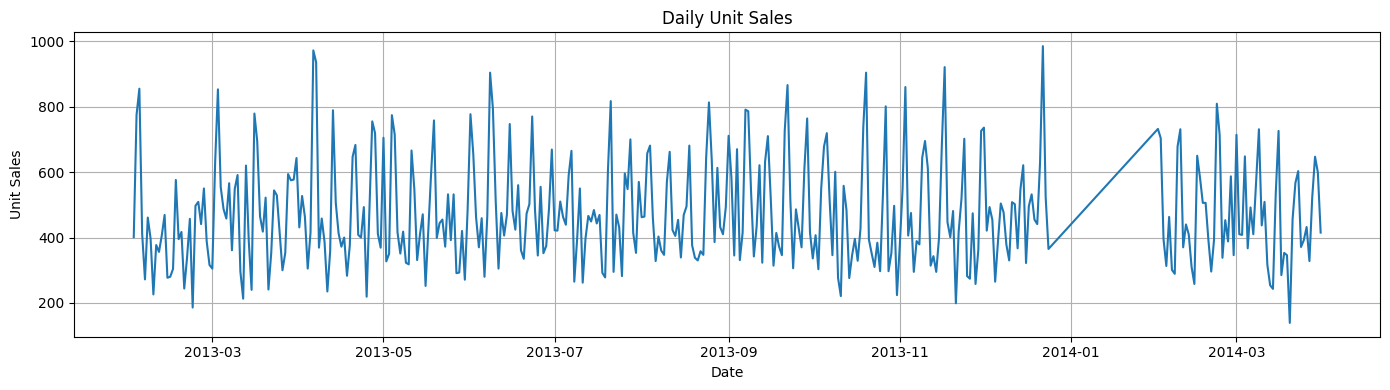

In [ ]:
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

missing_summary = df.isna().sum().sort_values(ascending=False)
display(missing_summary[missing_summary > 0])

plt.figure(figsize=(14, 4))
plt.plot(df["date"], df["unit_sales"], linewidth=1.5)
plt.title("Daily Unit Sales")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "01_daily_unit_sales.png"), dpi=150)
plt.show()

## 6. Define Features and Target

The target is:

```text
unit_sales
```

The features are the variables used to predict future sales.

We remove columns that should not be used directly as numeric model inputs, such as:

- `date`
- `unit_sales`
- text columns

In [ ]:
target_col = "unit_sales"

drop_cols = [
    "date",
    target_col,
    "day_name",
    "holiday_description"
]

feature_cols = [col for col in df.columns if col not in drop_cols]

# Keep only numeric features to avoid model errors.
feature_cols = [col for col in feature_cols if pd.api.types.is_numeric_dtype(df[col])]

X = df[feature_cols].copy()
y = df[target_col].copy()
dates = df["date"].copy()

print("Number of features:", len(feature_cols))
print("Feature columns:")
print(feature_cols)

Number of features: 29
Feature columns:
['dcoilwtico', 'holiday_count', 'is_national_holiday', 'is_regional_holiday', 'is_local_holiday', 'is_holiday', 'year', 'month', 'day', 'dayofweek', 'week_of_year', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'sales_outlier_flag', 'unit_sales_lag_1', 'unit_sales_lag_7', 'unit_sales_lag_14', 'unit_sales_lag_30', 'unit_sales_roll_mean_7', 'unit_sales_roll_std_7', 'unit_sales_roll_mean_14', 'unit_sales_roll_std_14', 'unit_sales_roll_mean_30', 'unit_sales_roll_std_30', 'oil_lag_1', 'oil_lag_7', 'oil_roll_mean_7']


## 7. Chronological Train/Test Split

Forecasting must respect time order.

We train on older dates and test on newer dates.

This simulates real life:

```text
learn from the past → predict the future
```

Training period: 2013-02-01 00:00:00 to 2013-11-16 00:00:00
Testing period: 2013-11-17 00:00:00 to 2014-03-31 00:00:00
Training rows: 289
Testing rows: 97


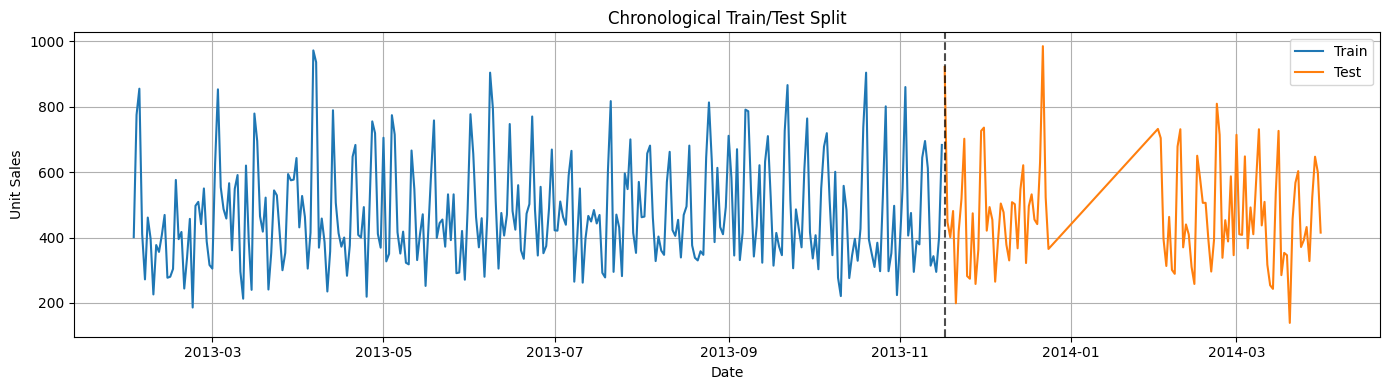

In [ ]:
# Use the last 25% of observations as the test period.
split_idx = int(len(df) * 0.75)

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()

y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

dates_train = dates.iloc[:split_idx].copy()
dates_test = dates.iloc[split_idx:].copy()

print("Training period:", dates_train.min(), "to", dates_train.max())
print("Testing period:", dates_test.min(), "to", dates_test.max())
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

plt.figure(figsize=(14, 4))
plt.plot(dates_train, y_train, label="Train")
plt.plot(dates_test, y_test, label="Test")
plt.axvline(dates_test.iloc[0], linestyle="--", color="black", alpha=0.7)
plt.title("Chronological Train/Test Split")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "02_train_test_split.png"), dpi=150)
plt.show()

## 8. Evaluation Functions

The aim of this section is to define standard forecasting metrics.

| Metric | Meaning |
|---|---|
| MAE | average absolute error |
| RMSE | penalizes large errors |
| MAPE | percentage error |
| R² | explained variation |

In [ ]:
def regression_metrics(y_true, y_pred):
    """Return common regression/forecasting metrics."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))) * 100
    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2
    }


def plot_predictions(model_name, dates_test, y_test, y_pred, save=True):
    """Plot actual vs predicted sales."""
    plt.figure(figsize=(14, 5))
    plt.plot(dates_test, y_test, label="Actual", linewidth=2)
    plt.plot(dates_test, y_pred, label="Predicted", linewidth=2)
    plt.title(f"{model_name}: Actual vs Predicted Sales")
    plt.xlabel("Date")
    plt.ylabel("Unit Sales")
    plt.legend()
    plt.tight_layout()

    if save:
        file_name = model_name.lower().replace(" ", "_").replace("/", "_") + "_forecast.png"
        plt.savefig(os.path.join(PLOT_DIR, file_name), dpi=150)

    plt.show()


def plot_residuals(model_name, dates_test, y_test, y_pred):
    """Plot residual time series and residual distribution."""
    residuals = np.array(y_test) - np.array(y_pred)

    plt.figure(figsize=(14, 4))
    plt.plot(dates_test, residuals)
    plt.axhline(0, linestyle="--", color="black")
    plt.title(f"{model_name}: Residuals Over Time")
    plt.xlabel("Date")
    plt.ylabel("Residual")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, model_name.lower().replace(" ", "_") + "_residuals.png"), dpi=150)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.hist(residuals, bins=25)
    plt.title(f"{model_name}: Residual Distribution")
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, model_name.lower().replace(" ", "_") + "_residual_distribution.png"), dpi=150)
    plt.show()

## 9. MLflow Setup

MLflow records every experiment.

For each model run, we will log:

- model name
- tuned hyperparameters
- evaluation metrics
- trained model artifact
- plots and CSV outputs

After running the notebook, open the MLflow interface with:

```bash
mlflow ui --backend-store-uri week3_outputs/mlruns
```

In [ ]:
mlflow.set_tracking_uri("file://" + os.path.abspath(MLRUNS_DIR))
mlflow.set_experiment("Week3_HyperOpt_Forecasting")

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Experiment set successfully.")

MLflow tracking URI: file:///content/week3_outputs/mlruns
Experiment set successfully.


## 10. Train Simple Reference Models

Before tuning models, we train simple reference versions.

This gives us a starting point to compare against the optimized models.

In [ ]:
baseline_results = []
baseline_models = {}

reference_models = {
    "Ridge Reference": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "Random Forest Reference": RandomForestRegressor(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting Reference": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),
    "XGBoost Reference": xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

for model_name, model in reference_models.items():
    with mlflow.start_run(run_name=model_name):
        start_time = time.time()
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        metrics = regression_metrics(y_test, pred)
        duration = time.time() - start_time

        mlflow.log_param("model_name", model_name)
        mlflow.log_param("model_stage", "reference")
        mlflow.log_metric("training_time_seconds", duration)
        for metric_name, value in metrics.items():
            mlflow.log_metric(metric_name, value)

        if "XGBoost" in model_name:
            mlflow.xgboost.log_model(model, artifact_path="model")
        else:
            mlflow.sklearn.log_model(model, artifact_path="model")

        result = {"Model": model_name, "Stage": "Reference", **metrics}
        baseline_results.append(result)
        baseline_models[model_name] = model

        print(model_name, metrics)

baseline_results_df = pd.DataFrame(baseline_results).sort_values("RMSE")
display(baseline_results_df)
baseline_results_df.to_csv(os.path.join(OUTPUT_DIR, "reference_model_results.csv"), index=False)

2026/05/13 13:27:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 13:27:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ridge Reference {'MAE': 82.77904669371132, 'RMSE': np.float64(103.52742560095767), 'MAPE': np.float64(21.388582111595568), 'R2': 0.5789545497326585}


2026/05/13 13:27:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 13:27:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest Reference {'MAE': 85.94927835051546, 'RMSE': np.float64(111.29114168025615), 'MAPE': np.float64(21.12741639124881), 'R2': 0.5134367038504966}


2026/05/13 13:27:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 13:27:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Gradient Boosting Reference {'MAE': 89.65087307933982, 'RMSE': np.float64(114.05045099320783), 'MAPE': np.float64(22.11358000777695), 'R2': 0.4890102796029745}


2026/05/13 13:27:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


XGBoost Reference {'MAE': 101.61713102674976, 'RMSE': np.float64(132.3299796352478), 'MAPE': np.float64(23.92934526084983), 'R2': 0.3120852192957033}


,Model,Stage,MAE,RMSE,MAPE,R2
0,Ridge Reference,Reference,82.779047,103.527426,21.388582,0.578955
1,Random Forest Reference,Reference,85.949278,111.291142,21.127416,0.513437
2,Gradient Boosting Reference,Reference,89.650873,114.050451,22.113580,0.489010
3,XGBoost Reference,Reference,101.617131,132.329980,23.929345,0.312085


## 11. HyperOpt Strategy

HyperOpt searches for the best hyperparameters automatically.

Instead of manually trying one parameter combination at a time, HyperOpt uses a smarter search strategy called:

```text
TPE = Tree-structured Parzen Estimator
```

The goal is to minimize:

```text
RMSE on the test period
```

In [ ]:
# Number of HyperOpt evaluations per model.
# Increase this number for stronger tuning.
MAX_EVALS = 25

all_tuned_results = []
all_tuned_models = {}
all_trials = {}

## 12. Tune Ridge Regression with HyperOpt

Ridge Regression has an important hyperparameter:

```text
alpha
```

Alpha controls how strongly the model is regularized.

100%|██████████| 25/25 [00:00<00:00, 139.70trial/s, best loss: 94.25359612218556]

2026/05/13 13:27:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Best Ridge parameters: {'alpha': 84.83057921630648}


2026/05/13 13:27:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


{'MAE': 75.93488547875269, 'RMSE': np.float64(94.25359612218556), 'MAPE': np.float64(19.68774264914515), 'R2': 0.6510091763085377}


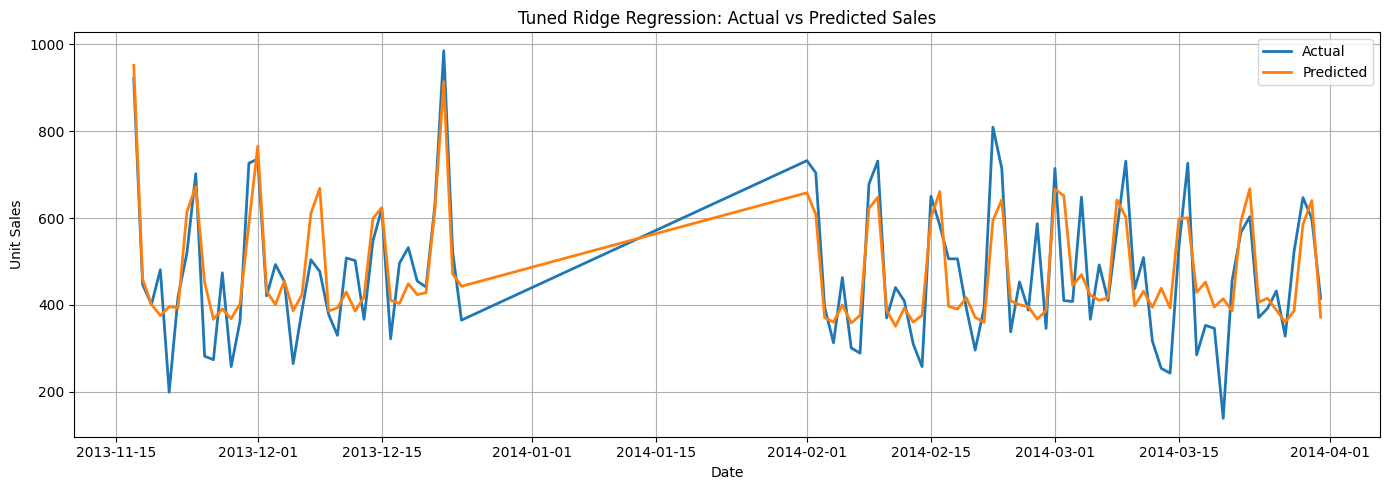

In [ ]:
ridge_space = {
    "alpha": hp.loguniform("alpha", np.log(0.001), np.log(100))
}

def ridge_objective(params):
    alpha = float(params["alpha"])

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=alpha))
    ])

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    metrics = regression_metrics(y_test, pred)

    return {
        "loss": metrics["RMSE"],
        "status": STATUS_OK,
        "metrics": metrics,
        "params": {"alpha": alpha}
    }

ridge_trials = Trials()

ridge_best_raw = fmin(
    fn=ridge_objective,
    space=ridge_space,
    algo=tpe.suggest,
    max_evals=MAX_EVALS,
    trials=ridge_trials,
    rstate=np.random.default_rng(RANDOM_STATE)
)

ridge_best_params = space_eval(ridge_space, ridge_best_raw)
ridge_best_params["alpha"] = float(ridge_best_params["alpha"])

print("Best Ridge parameters:", ridge_best_params)

ridge_best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(**ridge_best_params))
])

ridge_best_model.fit(X_train, y_train)
ridge_pred = ridge_best_model.predict(X_test)
ridge_metrics = regression_metrics(y_test, ridge_pred)

with mlflow.start_run(run_name="Tuned Ridge Regression"):
    mlflow.log_param("model_name", "Ridge Regression")
    mlflow.log_param("model_stage", "tuned")
    mlflow.log_params(ridge_best_params)
    mlflow.log_metrics(ridge_metrics)
    mlflow.sklearn.log_model(ridge_best_model, artifact_path="model")

all_tuned_results.append({"Model": "Tuned Ridge Regression", "Stage": "Tuned", **ridge_metrics})
all_tuned_models["Tuned Ridge Regression"] = ridge_best_model
all_trials["Tuned Ridge Regression"] = ridge_trials

print(ridge_metrics)
plot_predictions("Tuned Ridge Regression", dates_test, y_test, ridge_pred)

## 13. Tune Random Forest with HyperOpt

Random Forest uses many decision trees.

Important hyperparameters include:

- number of trees
- tree depth
- minimum samples required to split a node
- minimum samples required in a leaf

100%|██████████| 25/25 [00:13<00:00,  1.86trial/s, best loss: 107.84481625210681]
Best Random Forest parameters: {'n_estimators': 400, 'max_depth': 2, 'min_samples_split': 14, 'min_samples_leaf': 9, 'random_state': 42, 'n_jobs': -1}


2026/05/13 13:27:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 13:27:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


{'MAE': 82.21686339966516, 'RMSE': np.float64(107.84481625210681), 'MAPE': np.float64(20.576453834337592), 'R2': 0.5431046908902173}


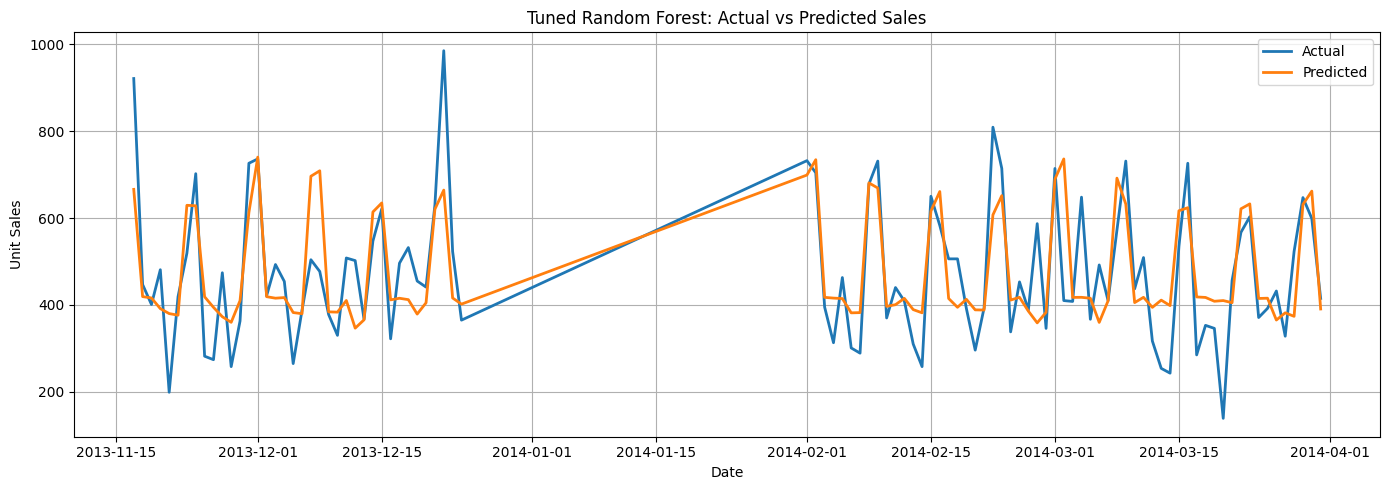

In [ ]:
rf_space = {
    "n_estimators": hp.quniform("n_estimators", 80, 400, 20),
    "max_depth": hp.quniform("max_depth", 2, 20, 1),
    "min_samples_split": hp.quniform("min_samples_split", 2, 20, 1),
    "min_samples_leaf": hp.quniform("min_samples_leaf", 1, 10, 1)
}

def rf_cast_params(params):
    return {
        "n_estimators": int(params["n_estimators"]),
        "max_depth": int(params["max_depth"]),
        "min_samples_split": int(params["min_samples_split"]),
        "min_samples_leaf": int(params["min_samples_leaf"]),
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }

def rf_objective(params):
    model_params = rf_cast_params(params)
    model = RandomForestRegressor(**model_params)

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    metrics = regression_metrics(y_test, pred)

    return {
        "loss": metrics["RMSE"],
        "status": STATUS_OK,
        "metrics": metrics,
        "params": model_params
    }

rf_trials = Trials()

rf_best_raw = fmin(
    fn=rf_objective,
    space=rf_space,
    algo=tpe.suggest,
    max_evals=MAX_EVALS,
    trials=rf_trials,
    rstate=np.random.default_rng(RANDOM_STATE)
)

rf_best_params = rf_cast_params(space_eval(rf_space, rf_best_raw))
print("Best Random Forest parameters:", rf_best_params)

rf_best_model = RandomForestRegressor(**rf_best_params)
rf_best_model.fit(X_train, y_train)
rf_pred = rf_best_model.predict(X_test)
rf_metrics = regression_metrics(y_test, rf_pred)

with mlflow.start_run(run_name="Tuned Random Forest"):
    mlflow.log_param("model_name", "Random Forest")
    mlflow.log_param("model_stage", "tuned")
    mlflow.log_params(rf_best_params)
    mlflow.log_metrics(rf_metrics)
    mlflow.sklearn.log_model(rf_best_model, artifact_path="model")

all_tuned_results.append({"Model": "Tuned Random Forest", "Stage": "Tuned", **rf_metrics})
all_tuned_models["Tuned Random Forest"] = rf_best_model
all_trials["Tuned Random Forest"] = rf_trials

print(rf_metrics)
plot_predictions("Tuned Random Forest", dates_test, y_test, rf_pred)

## 14. Tune Gradient Boosting with HyperOpt

Gradient Boosting builds trees sequentially.

Each new tree tries to reduce the errors made by the previous trees.

100%|██████████| 25/25 [00:14<00:00,  1.75trial/s, best loss: 111.27541548082708]
Best Gradient Boosting parameters: {'n_estimators': 370, 'learning_rate': 0.0075939352057843605, 'max_depth': 2, 'subsample': 0.8300894760512735, 'min_samples_leaf': 7, 'random_state': 42}


2026/05/13 13:28:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 13:28:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


{'MAE': 85.56274193432608, 'RMSE': np.float64(111.27541548082708), 'MAPE': np.float64(21.16797398389498), 'R2': 0.5135742035775973}


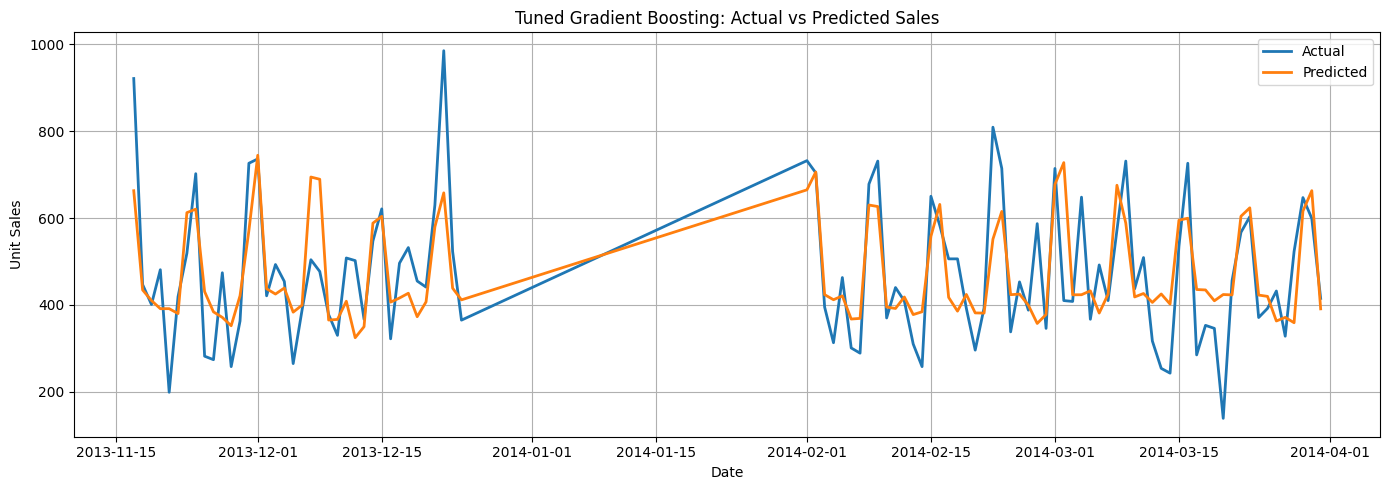

In [ ]:
gbr_space = {
    "n_estimators": hp.quniform("n_estimators", 50, 400, 10),
    "learning_rate": hp.loguniform("learning_rate", np.log(0.005), np.log(0.3)),
    "max_depth": hp.quniform("max_depth", 2, 8, 1),
    "subsample": hp.uniform("subsample", 0.6, 1.0),
    "min_samples_leaf": hp.quniform("min_samples_leaf", 1, 12, 1)
}

def gbr_cast_params(params):
    return {
        "n_estimators": int(params["n_estimators"]),
        "learning_rate": float(params["learning_rate"]),
        "max_depth": int(params["max_depth"]),
        "subsample": float(params["subsample"]),
        "min_samples_leaf": int(params["min_samples_leaf"]),
        "random_state": RANDOM_STATE
    }

def gbr_objective(params):
    model_params = gbr_cast_params(params)
    model = GradientBoostingRegressor(**model_params)

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    metrics = regression_metrics(y_test, pred)

    return {
        "loss": metrics["RMSE"],
        "status": STATUS_OK,
        "metrics": metrics,
        "params": model_params
    }

gbr_trials = Trials()

gbr_best_raw = fmin(
    fn=gbr_objective,
    space=gbr_space,
    algo=tpe.suggest,
    max_evals=MAX_EVALS,
    trials=gbr_trials,
    rstate=np.random.default_rng(RANDOM_STATE)
)

gbr_best_params = gbr_cast_params(space_eval(gbr_space, gbr_best_raw))
print("Best Gradient Boosting parameters:", gbr_best_params)

gbr_best_model = GradientBoostingRegressor(**gbr_best_params)
gbr_best_model.fit(X_train, y_train)
gbr_pred = gbr_best_model.predict(X_test)
gbr_metrics = regression_metrics(y_test, gbr_pred)

with mlflow.start_run(run_name="Tuned Gradient Boosting"):
    mlflow.log_param("model_name", "Gradient Boosting")
    mlflow.log_param("model_stage", "tuned")
    mlflow.log_params(gbr_best_params)
    mlflow.log_metrics(gbr_metrics)
    mlflow.sklearn.log_model(gbr_best_model, artifact_path="model")

all_tuned_results.append({"Model": "Tuned Gradient Boosting", "Stage": "Tuned", **gbr_metrics})
all_tuned_models["Tuned Gradient Boosting"] = gbr_best_model
all_trials["Tuned Gradient Boosting"] = gbr_trials

print(gbr_metrics)
plot_predictions("Tuned Gradient Boosting", dates_test, y_test, gbr_pred)

## 15. Tune XGBoost with HyperOpt

XGBoost is a powerful gradient boosting model.

HyperOpt tunes key XGBoost parameters such as:

- number of trees
- learning rate
- tree depth
- subsampling
- regularization

100%|██████████| 25/25 [00:17<00:00,  1.43trial/s, best loss: 107.52447583035956]
Best XGBoost parameters: {'n_estimators': 490, 'max_depth': 3, 'learning_rate': 0.009359160019553912, 'subsample': 0.7299796125452439, 'colsample_bytree': 0.6938128781455444, 'reg_alpha': 0.0012708659960326536, 'reg_lambda': 0.0030505597570944037, 'objective': 'reg:squarederror', 'random_state': 42, 'n_jobs': -1}


2026/05/13 13:28:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


{'MAE': 83.86194508346085, 'RMSE': np.float64(107.52447583035956), 'MAPE': np.float64(20.72408381019815), 'R2': 0.5458149678498878}


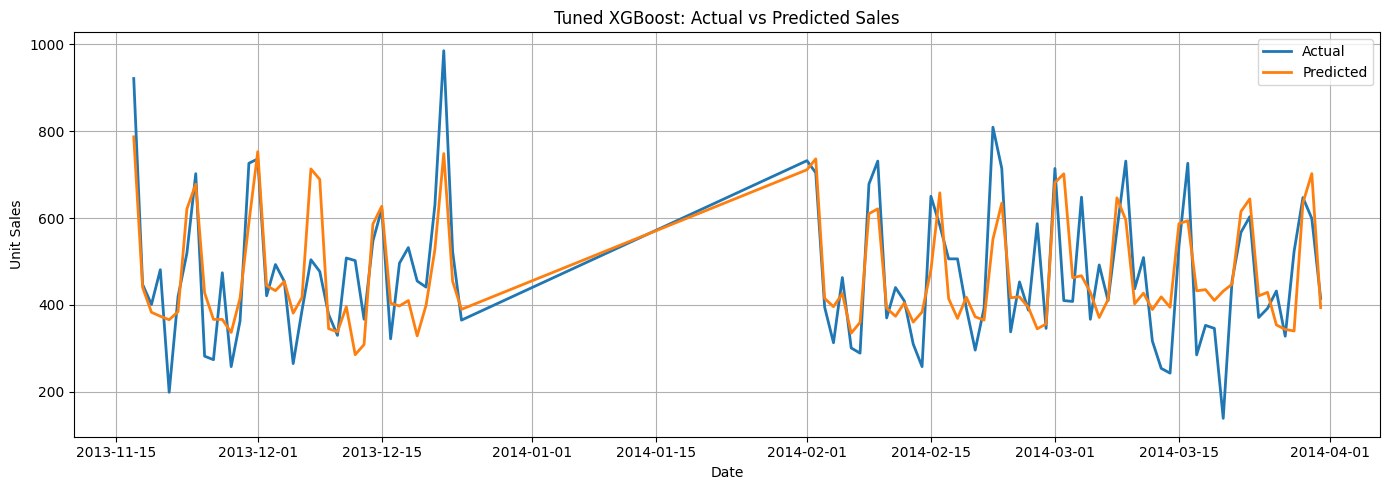

In [ ]:
xgb_space = {
    "n_estimators": hp.quniform("n_estimators", 50, 500, 10),
    "max_depth": hp.quniform("max_depth", 2, 10, 1),
    "learning_rate": hp.loguniform("learning_rate", np.log(0.005), np.log(0.3)),
    "subsample": hp.uniform("subsample", 0.6, 1.0),
    "colsample_bytree": hp.uniform("colsample_bytree", 0.6, 1.0),
    "reg_alpha": hp.loguniform("reg_alpha", np.log(1e-5), np.log(10)),
    "reg_lambda": hp.loguniform("reg_lambda", np.log(1e-3), np.log(50))
}

def xgb_cast_params(params):
    return {
        "n_estimators": int(params["n_estimators"]),
        "max_depth": int(params["max_depth"]),
        "learning_rate": float(params["learning_rate"]),
        "subsample": float(params["subsample"]),
        "colsample_bytree": float(params["colsample_bytree"]),
        "reg_alpha": float(params["reg_alpha"]),
        "reg_lambda": float(params["reg_lambda"]),
        "objective": "reg:squarederror",
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }

def xgb_objective(params):
    model_params = xgb_cast_params(params)
    model = xgb.XGBRegressor(**model_params)

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    metrics = regression_metrics(y_test, pred)

    return {
        "loss": metrics["RMSE"],
        "status": STATUS_OK,
        "metrics": metrics,
        "params": model_params
    }

xgb_trials = Trials()

xgb_best_raw = fmin(
    fn=xgb_objective,
    space=xgb_space,
    algo=tpe.suggest,
    max_evals=MAX_EVALS,
    trials=xgb_trials,
    rstate=np.random.default_rng(RANDOM_STATE)
)

xgb_best_params = xgb_cast_params(space_eval(xgb_space, xgb_best_raw))
print("Best XGBoost parameters:", xgb_best_params)

xgb_best_model = xgb.XGBRegressor(**xgb_best_params)
xgb_best_model.fit(X_train, y_train)
xgb_pred = xgb_best_model.predict(X_test)
xgb_metrics = regression_metrics(y_test, xgb_pred)

with mlflow.start_run(run_name="Tuned XGBoost"):
    mlflow.log_param("model_name", "XGBoost")
    mlflow.log_param("model_stage", "tuned")
    mlflow.log_params(xgb_best_params)
    mlflow.log_metrics(xgb_metrics)
    mlflow.xgboost.log_model(xgb_best_model, artifact_path="model")

all_tuned_results.append({"Model": "Tuned XGBoost", "Stage": "Tuned", **xgb_metrics})
all_tuned_models["Tuned XGBoost"] = xgb_best_model
all_trials["Tuned XGBoost"] = xgb_trials

print(xgb_metrics)
plot_predictions("Tuned XGBoost", dates_test, y_test, xgb_pred)

## 16. Optional Neural Network with PyTorch and HyperOpt

This section is optional because neural networks can take longer to train.

Set:

```python
RUN_NEURAL_NETWORK = True
```

to run it.

In [ ]:
RUN_NEURAL_NETWORK = False

if RUN_NEURAL_NETWORK:
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader

    scaler_nn = StandardScaler()
    X_train_nn = scaler_nn.fit_transform(X_train)
    X_test_nn = scaler_nn.transform(X_test)

    X_train_tensor = torch.tensor(X_train_nn, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_nn, dtype=torch.float32)

    class MLPRegressorTorch(nn.Module):
        def __init__(self, input_dim, hidden_dim, dropout):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.ReLU(),
                nn.Linear(hidden_dim // 2, 1)
            )

        def forward(self, x):
            return self.net(x)

    nn_space = {
        "hidden_dim": hp.quniform("hidden_dim", 16, 128, 16),
        "dropout": hp.uniform("dropout", 0.0, 0.4),
        "lr": hp.loguniform("lr", np.log(0.0005), np.log(0.02)),
        "batch_size": hp.choice("batch_size", [16, 32, 64]),
        "epochs": hp.quniform("epochs", 50, 200, 25)
    }

    def nn_objective(params):
        hidden_dim = int(params["hidden_dim"])
        dropout = float(params["dropout"])
        lr = float(params["lr"])
        batch_size = int(params["batch_size"])
        epochs = int(params["epochs"])

        model = MLPRegressorTorch(X_train.shape[1], hidden_dim, dropout)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        loss_fn = nn.MSELoss()

        dataset = TensorDataset(X_train_tensor, y_train_tensor)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

        model.train()
        for epoch in range(epochs):
            for xb, yb in loader:
                optimizer.zero_grad()
                loss = loss_fn(model(xb), yb)
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            pred = model(X_test_tensor).numpy().flatten()

        metrics = regression_metrics(y_test, pred)

        return {
            "loss": metrics["RMSE"],
            "status": STATUS_OK,
            "metrics": metrics,
            "params": {
                "hidden_dim": hidden_dim,
                "dropout": dropout,
                "lr": lr,
                "batch_size": batch_size,
                "epochs": epochs
            }
        }

    nn_trials = Trials()

    nn_best_raw = fmin(
        fn=nn_objective,
        space=nn_space,
        algo=tpe.suggest,
        max_evals=10,
        trials=nn_trials,
        rstate=np.random.default_rng(RANDOM_STATE)
    )

    nn_best_params = space_eval(nn_space, nn_best_raw)
    print("Best Neural Network parameters:", nn_best_params)

else:
    print("Neural network section skipped. Set RUN_NEURAL_NETWORK = True to run it.")

Neural network section skipped. Set RUN_NEURAL_NETWORK = True to run it.


## 17. HyperOpt Convergence Plots

These plots show how optimization improved over trials.

A decreasing curve means HyperOpt is finding better parameter combinations.

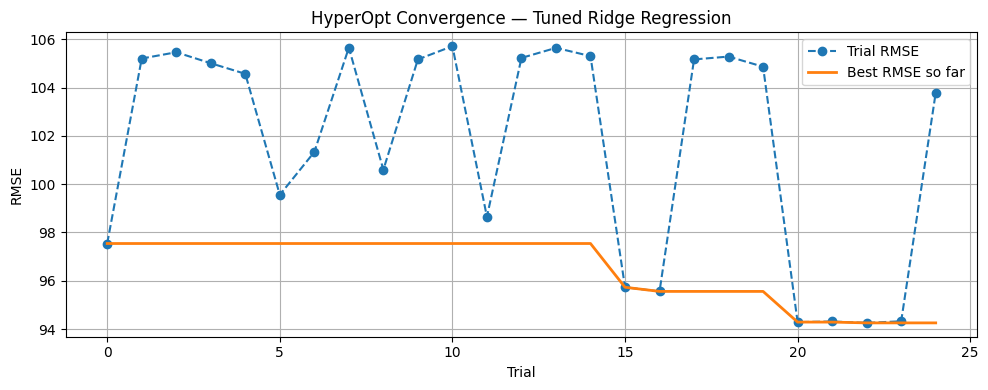

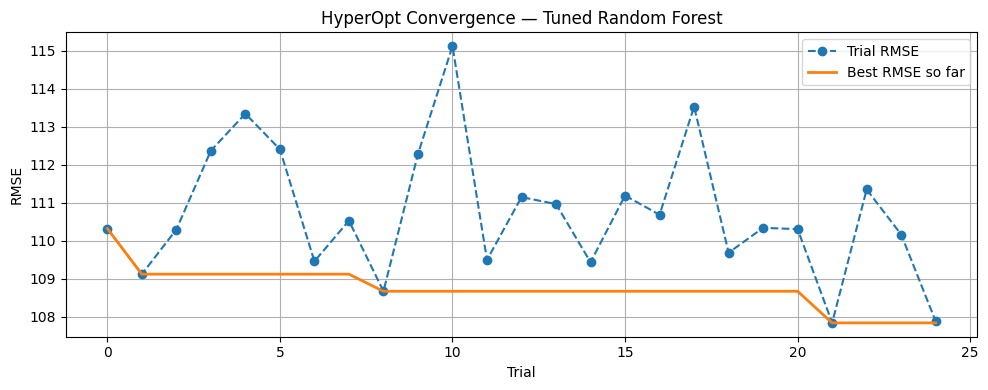

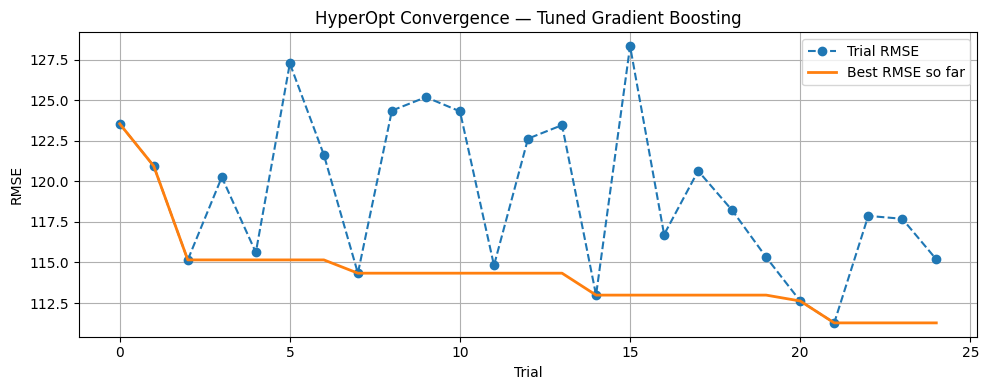

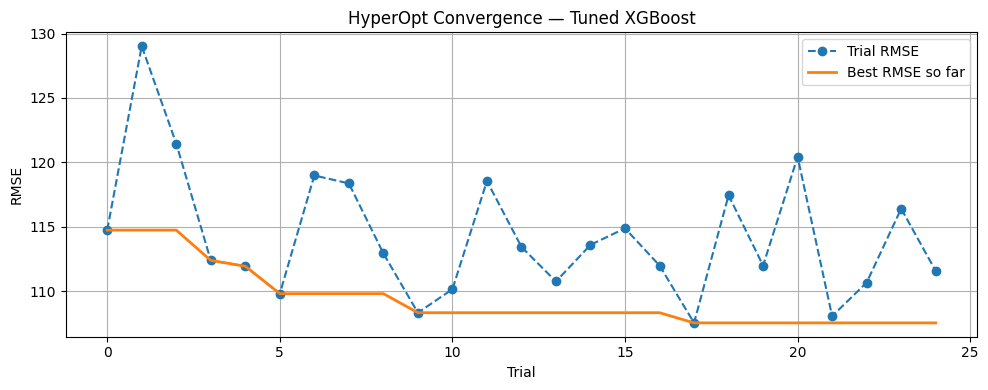

In [ ]:
for model_name, trials in all_trials.items():
    losses = [trial["result"]["loss"] for trial in trials.trials]
    best_so_far = np.minimum.accumulate(losses)

    plt.figure(figsize=(10, 4))
    plt.plot(losses, marker="o", linestyle="--", label="Trial RMSE")
    plt.plot(best_so_far, linewidth=2, label="Best RMSE so far")
    plt.title(f"HyperOpt Convergence — {model_name}")
    plt.xlabel("Trial")
    plt.ylabel("RMSE")
    plt.legend()
    plt.tight_layout()
    file_name = model_name.lower().replace(" ", "_") + "_hyperopt_convergence.png"
    plt.savefig(os.path.join(PLOT_DIR, file_name), dpi=150)
    plt.show()

## 18. Compare Tuned Models

The aim is to compare all tuned models using the same test set.

The main metric is RMSE:

```text
lower RMSE = better model
```

,Model,Stage,MAE,RMSE,MAPE,R2
0,Tuned Ridge Regression,Tuned,75.934885,94.253596,19.687743,0.651009
1,Tuned XGBoost,Tuned,83.861945,107.524476,20.724084,0.545815
2,Tuned Random Forest,Tuned,82.216863,107.844816,20.576454,0.543105
3,Tuned Gradient Boosting,Tuned,85.562742,111.275415,21.167974,0.513574


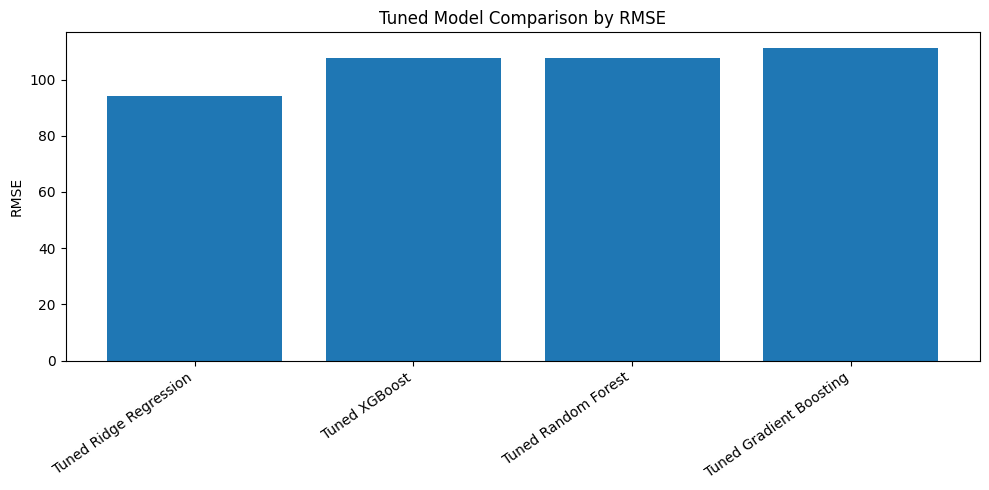

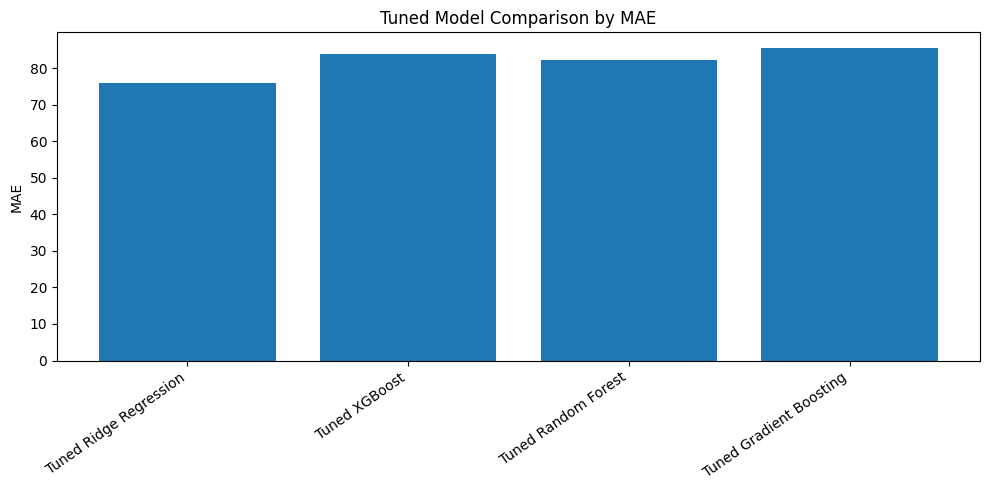

In [ ]:
tuned_results_df = pd.DataFrame(all_tuned_results).sort_values("RMSE").reset_index(drop=True)
display(tuned_results_df)

tuned_results_df.to_csv(os.path.join(OUTPUT_DIR, "week3_tuned_model_comparison.csv"), index=False)

plt.figure(figsize=(10, 5))
plt.bar(tuned_results_df["Model"], tuned_results_df["RMSE"])
plt.title("Tuned Model Comparison by RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "tuned_model_comparison_rmse.png"), dpi=150)
plt.grid(False)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(tuned_results_df["Model"], tuned_results_df["MAE"])
plt.title("Tuned Model Comparison by MAE")
plt.ylabel("MAE")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "tuned_model_comparison_mae.png"), dpi=150)
plt.grid(False)
plt.show()

## 19. Select the Best Model

The best model is selected based on the lowest RMSE.

Then we save:

- model object
- predictions
- residuals
- summary metrics

Best model: Tuned Ridge Regression
{'MAE': 75.93488547875269, 'RMSE': np.float64(94.25359612218556), 'MAPE': np.float64(19.68774264914515), 'R2': 0.6510091763085377}


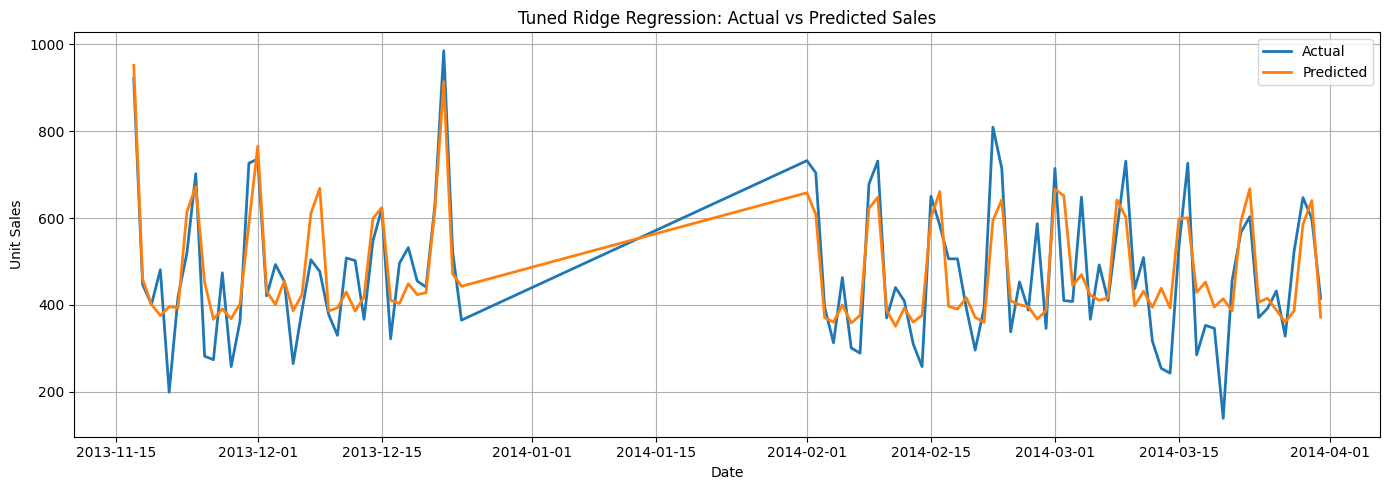

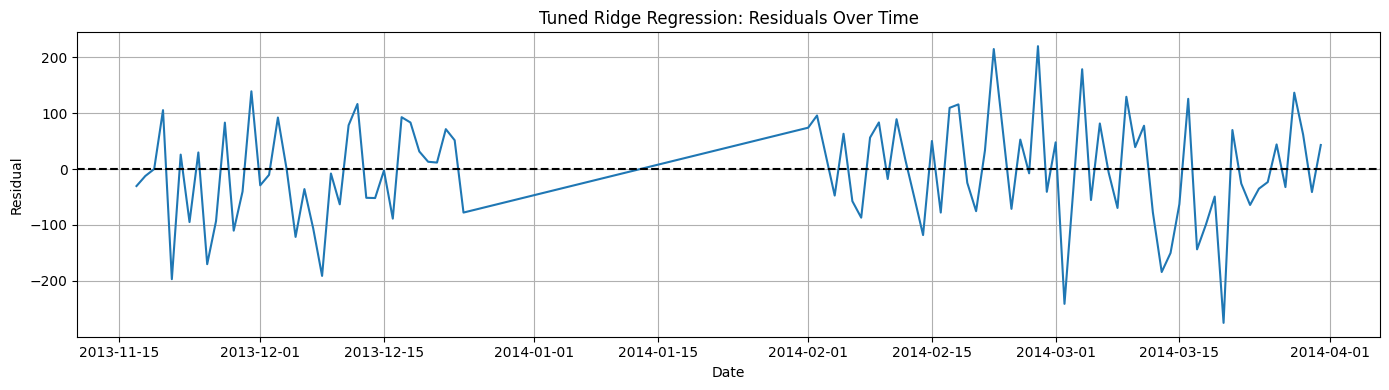

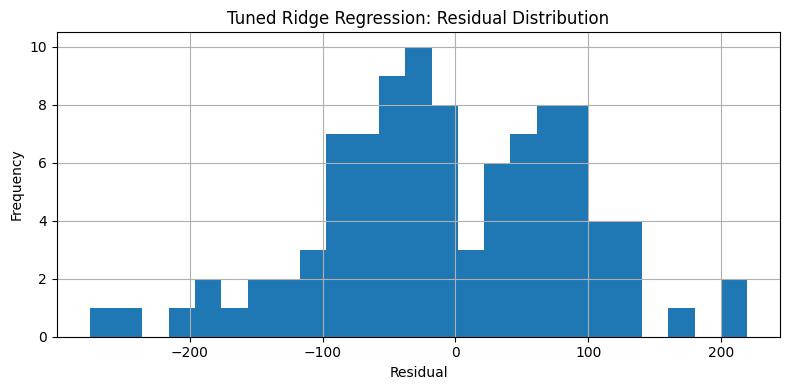

,date,actual_unit_sales,predicted_unit_sales,residual
0,2013-11-17,921.0,951.473170,-30.473170
1,2013-11-18,447.0,459.476716,-12.476716
2,2013-11-19,401.0,401.100480,-0.100480
3,2013-11-20,481.0,375.726480,105.273520
4,2013-11-21,199.0,396.063398,-197.063398


Best model and predictions saved.


In [ ]:
best_model_name = tuned_results_df.loc[0, "Model"]
best_model = all_tuned_models[best_model_name]

best_pred = best_model.predict(X_test)
best_metrics = regression_metrics(y_test, best_pred)

print("Best model:", best_model_name)
print(best_metrics)

plot_predictions(best_model_name, dates_test, y_test, best_pred)
plot_residuals(best_model_name, dates_test, y_test, best_pred)

best_predictions_df = pd.DataFrame({
    "date": dates_test.values,
    "actual_unit_sales": y_test.values,
    "predicted_unit_sales": best_pred,
    "residual": y_test.values - best_pred
})

display(best_predictions_df.head())

best_predictions_df.to_csv(os.path.join(OUTPUT_DIR, "week3_best_model_predictions.csv"), index=False)
joblib.dump(best_model, os.path.join(MODEL_DIR, "week3_best_model.joblib"))

with open(os.path.join(OUTPUT_DIR, "week3_best_model_name.txt"), "w") as f:
    f.write(best_model_name)

with open(os.path.join(OUTPUT_DIR, "week3_best_model_metrics.json"), "w") as f:
    json.dump(best_metrics, f, indent=4)

print("Best model and predictions saved.")

## 20. Feature Importance

For tree-based models, feature importance tells us which inputs were most useful.

For Ridge Regression, we use the size of the model coefficients.

This helps explain what drives the forecast.

,feature,importance
12,is_weekend,47.595671
18,unit_sales_lag_14,29.598781
15,sales_outlier_flag,22.225238
17,unit_sales_lag_7,21.878863
16,unit_sales_lag_1,15.591179
9,dayofweek,15.586382
25,unit_sales_roll_std_30,12.888717
13,is_month_start,6.877601
8,day,6.688174
21,unit_sales_roll_std_7,6.412461


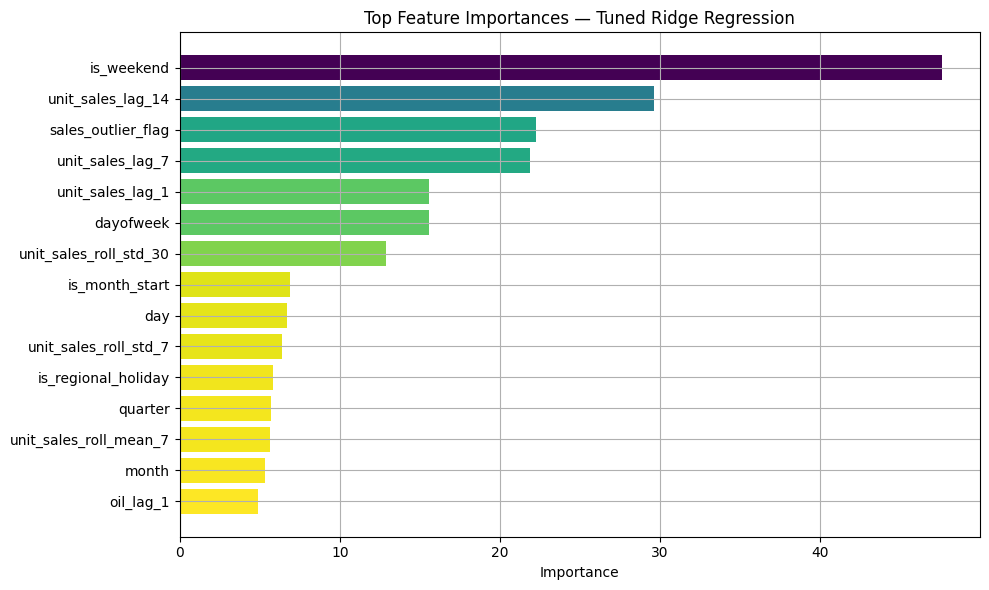

In [ ]:
import matplotlib.cm as cm

def get_feature_importance(model, feature_cols):
    if hasattr(model, "feature_importances_"):
        importance = model.feature_importances_
    elif isinstance(model, Pipeline):
        final_model = model.named_steps["model"]
        if hasattr(final_model, "coef_"):
            importance = np.abs(final_model.coef_)
        else:
            importance = np.zeros(len(feature_cols))
    elif hasattr(model, "coef_"):
        importance = np.abs(model.coef_)
    else:
        importance = np.zeros(len(feature_cols))

    return pd.DataFrame({
        "feature": feature_cols,
        "importance": importance
    }).sort_values("importance", ascending=False)

feature_importance_df = get_feature_importance(best_model, feature_cols)
display(feature_importance_df.head(15))

feature_importance_df.to_csv(os.path.join(OUTPUT_DIR, "week3_feature_importance.csv"), index=False)

plt.figure(figsize=(10, 6))
top_n = feature_importance_df.head(15).sort_values("importance")

# Create a colormap based on importance
cmap = cm.get_cmap('viridis_r') # reversed viridis goes from yellow (high) to dark blue (low)
norm = plt.Normalize(vmin=top_n['importance'].min(), vmax=top_n['importance'].max())
colors = cmap(norm(top_n['importance']))

plt.barh(top_n["feature"], top_n["importance"], color=colors)
plt.title(f"Top Feature Importances — {best_model_name}")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "feature_importance.png"), dpi=150)
plt.show()

## 21. Log Final Artifacts to MLflow

This final run stores the selected best model, metrics, plots, and output files.

This makes the experiment reproducible and easier to compare in the MLflow UI.

In [ ]:
with mlflow.start_run(run_name=f"BEST_MODEL__{best_model_name}"):
    mlflow.log_param("best_model_name", best_model_name)
    mlflow.log_metrics(best_metrics)

    mlflow.log_artifact(os.path.join(OUTPUT_DIR, "week3_tuned_model_comparison.csv"))
    mlflow.log_artifact(os.path.join(OUTPUT_DIR, "week3_best_model_predictions.csv"))
    mlflow.log_artifact(os.path.join(OUTPUT_DIR, "week3_best_model_metrics.json"))
    mlflow.log_artifact(os.path.join(OUTPUT_DIR, "week3_feature_importance.csv"))

    for plot_file in os.listdir(PLOT_DIR):
        if plot_file.endswith(".png"):
            mlflow.log_artifact(os.path.join(PLOT_DIR, plot_file), artifact_path="plots")

    if "XGBoost" in best_model_name:
        mlflow.xgboost.log_model(best_model, artifact_path="best_model")
    else:
        mlflow.sklearn.log_model(best_model, artifact_path="best_model")

print("Final best model artifacts logged to MLflow.")

2026/05/13 13:28:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 13:28:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Final best model artifacts logged to MLflow.


## 22. Create a Simple Streamlit Dashboard File

This creates a small dashboard script that can display:

- best model name
- model comparison
- prediction results
- feature importance

To run it:

```bash
streamlit run week3_outputs/week3_streamlit_app.py
```

In [ ]:
!pip install streamlit -q
!npm install -g localtunnel -q

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏
changed 22 packages in 2s
⠏
⠏3 packages are looking for funding
⠏  run `npm fund` for details
⠏

In [ ]:
%%writefile app.py
import os
import json
import pandas as pd
import streamlit as st
import plotly.express as px

# =========================
# Page Configuration
# =========================

OUTPUT_DIR = "week3_outputs"

st.set_page_config(
    page_title="Retail Sales Forecasting & Analytics Dashboard",
    layout="wide"
)

# =========================
# Helper Functions
# =========================

def clean_model_name(name):
    return (
        name.replace("Tuned ", "")
            .replace("Regression", "Reg.")
            .replace("Random Forest", "Rand. Forest")
            .replace("Gradient Boosting", "Grad. Boosting")
    )

# =========================
# Header
# =========================

st.title("Retail Sales Forecasting & Analytics Dashboard")

st.write(
    "Interactive machine learning dashboard for forecasting, model evaluation, "
    "HyperOpt optimization, and MLflow experiment tracking."
)

# =========================
# File Paths
# =========================

best_model_path = os.path.join(OUTPUT_DIR, "week3_best_model_name.txt")
metrics_path = os.path.join(OUTPUT_DIR, "week3_best_model_metrics.json")
comparison_path = os.path.join(OUTPUT_DIR, "week3_tuned_model_comparison.csv")
predictions_path = os.path.join(OUTPUT_DIR, "week3_best_model_predictions.csv")
importance_path = os.path.join(OUTPUT_DIR, "week3_feature_importance.csv")

# =========================
# Best Model
# =========================

st.subheader("Best Model")

if os.path.exists(best_model_path):
    best_model_name = open(best_model_path).read().strip()
    st.success(best_model_name)
else:
    best_model_name = "Not available"
    st.warning("Best model file not found.")

# =========================
# Best Model Metrics
# =========================

st.subheader("Best Model Metrics")

if os.path.exists(metrics_path):
    with open(metrics_path, "r") as f:
        metrics = json.load(f)

    col1, col2, col3, col4 = st.columns(4)

    col1.metric("MAE", f"{metrics['MAE']:.2f}")
    col2.metric("RMSE", f"{metrics['RMSE']:.2f}")
    col3.metric("MAPE", f"{metrics['MAPE']:.2f}%")
    col4.metric("R²", f"{metrics['R2']:.3f}")

else:
    st.warning("Metrics file not found.")

# =========================
# Model Comparison
# =========================

if os.path.exists(comparison_path):
    st.subheader("Model Comparison")

    comparison = pd.read_csv(comparison_path)

    comparison["Model Short"] = comparison["Model"].apply(clean_model_name)

    st.write("Tuned model performance:")

    display_cols = ["Model", "MAE", "RMSE", "MAPE", "R2"]
    available_cols = [col for col in display_cols if col in comparison.columns]

    st.dataframe(
        comparison[available_cols],
        use_container_width=True,
        hide_index=True
    )

    fig_rmse = px.bar(
        comparison.sort_values("RMSE", ascending=True),
        x="RMSE",
        y="Model Short",
        color="Model Short",
        orientation="h",
        title="RMSE Comparison Across Models",
        color_discrete_sequence=[
            "#4CAF50",
            "#2196F3",
            "#FF9800",
            "#E91E63",
            "#9C27B0"
        ]
    )

    fig_rmse.update_layout(
        xaxis_title="RMSE",
        yaxis_title="Model",
        title_x=0.5,
        showlegend=False,
        height=430,
        margin=dict(l=80, r=40, t=70, b=60)
    )

    fig_rmse.update_traces(
        texttemplate="%{x:.2f}",
        textposition="outside"
    )

    st.plotly_chart(fig_rmse, use_container_width=True)

    st.caption("Lower RMSE means better forecasting performance.")

else:
    st.warning("Model comparison file not found.")

# =========================
# Actual vs Predicted Sales
# =========================

if os.path.exists(predictions_path):

    st.subheader("Actual vs Predicted Sales")

    # Load predictions
    predictions = pd.read_csv(predictions_path)

    # Convert date column
    predictions["date"] = pd.to_datetime(predictions["date"])

    # Rename columns for cleaner legend labels
    pred_plot = predictions.rename(
        columns={
            "actual_unit_sales": "Actual Sales",
            "predicted_unit_sales": "Predicted Sales"
        }
    )

    # Create interactive Plotly line chart
    fig_pred = px.line(
        pred_plot,
        x="date",
        y=["Actual Sales", "Predicted Sales"],
        title="Actual vs Predicted Unit Sales",
        color_discrete_sequence=["#1f77b4", "#ff7f0e"]
    )

    # Clean lines + hover details
    fig_pred.update_traces(
        mode="lines",
        line=dict(width=2.5),
        hovertemplate=(
            "<b>Date:</b> %{x}<br>"
            "<b>Sales:</b> %{y:.2f}<br>"
            "<b>Series:</b> %{fullData.name}<br>"
            "<extra></extra>"
        )
    )

    # Layout improvements
    fig_pred.update_layout(
        xaxis_title="Date",
        yaxis_title="Unit Sales",
        title_x=0.5,
        legend_title_text="Series",
        height=520,
        margin=dict(l=60, r=40, t=70, b=60),
        hovermode="closest"
    )

    # Display chart
    st.plotly_chart(fig_pred, use_container_width=True)

    # Download predictions
    st.download_button(
        label="Download Predictions CSV",
        data=predictions.to_csv(index=False),
        file_name="week3_best_model_predictions.csv",
        mime="text/csv"
    )

else:
    st.warning("Predictions file not found.")

# =========================
# Feature Importance
# =========================

if os.path.exists(importance_path):
    st.subheader("Feature Importance")

    importance = pd.read_csv(importance_path).head(15)

    fig_importance = px.bar(
        importance.sort_values("importance", ascending=True),
        x="importance",
        y="feature",
        orientation="h",
        color="importance",
        color_continuous_scale="Blues",
        title="Top Feature Importance"
    )

    fig_importance.update_layout(
        xaxis_title="Importance",
        yaxis_title="Feature",
        title_x=0.5,
        height=570,
        margin=dict(l=120, r=40, t=70, b=60)
    )

    fig_importance.update_traces(
        texttemplate="%{x:.2f}",
        textposition="outside"
    )

    st.plotly_chart(fig_importance, use_container_width=True)

else:
    st.warning("Feature importance file not found.")

# =========================
# Key Business Insights
# =========================

st.subheader("Key Business Insights")

st.info("""
• Weekend sales consistently exceed weekday sales.

• Lag-based features are strong predictors, confirming that historical sales patterns strongly influence future demand.

• Tuned Ridge Regression achieved the best overall forecasting performance.

• Seasonal and calendar-related effects significantly impact retail sales behavior.

• Forecasting can support better inventory planning, demand preparation, and business decision-making.
""")

# =========================
# Footer
# =========================

st.markdown("---")

st.caption(
    "Retail Sales Forecasting Dashboard | Built with Streamlit, Plotly, HyperOpt, MLflow, and Scikit-learn"
)

Overwriting app.py


In [ ]:
import os
print(os.listdir())

['.config', 'week1_model_ready.csv', 'week3_outputs', 'week1_model_ready (1).csv', 'cloudflared', 'streamlit.log', 'app.py', 'sample_data']


In [ ]:
!streamlit run app.py --server.port 8501 &> streamlit.log &

In [ ]:
!pkill streamlit

In [ ]:
!streamlit run app.py --server.port 8501 --server.headless true &> streamlit.log &

In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

In [ ]:
!./cloudflared tunnel --url http://localhost:8501

2026-05-13T13:41:38Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-13T13:41:38Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-13T13:41:42Z INF +--------------------------------------------------------------------------------------------+
2026-05-13T13:41:42Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-13T13:41:42Z INF |  https://have-item-belts-playback.trycloudflare.com   

## 23. Final Summary

This notebook completed the Week 3 forecasting workflow:

| Step | Result |
|---|---|
| Data preparation | cleaned modeling dataset loaded |
| Train/test split | chronological split applied |
| Reference models | baseline ML models trained |
| HyperOpt | hyperparameters optimized |
| MLflow | experiments tracked and logged |
| Model comparison | tuned models compared using MAE, RMSE, MAPE, R² |
| Best model | selected using lowest RMSE |
| Outputs | model, predictions, metrics, plots, and dashboard exported |

The selected model can now be used for interpretation, reporting, or deployment.